# Minimal noisy-source Bayesian reasoning with Qwen3.5-4B

This notebook builds a noisy-channel decoding experiment. It generates a fixed observation block, computes the exact Bayesian posterior, and evaluates Qwen with forced-choice probes. Every scored evaluation is exactly one user-role message containing the rules, questions, SOURCE answers, probe, and response instruction. The `older` and `newer` rule prompts are evaluated on matched observation blocks for an A/B comparison.

**Prompt-format revision:** rerun the model-evaluation cells before interpreting rendered outputs or replacing saved result artifacts; earlier results used chat-role transcripts and are not directly comparable.

**Prompt A/B and statistic revision:** retained outputs and result artifacts that do not contain both `prompt_variant` and `candidate_agreement_statistics` predate this comparison. Rerun transcript generation, model evaluation, and analysis; analysis cells reject the stale schema instead of pooling it with current results.

## Experimental contract

- The secret $s$ is uniformly distributed over $\{1,\ldots,N\}$.
- For a membership proposition $q(s)$, Source A reports its truth value with probability $r$ and the opposite value with probability $1-r$. Answers are conditionally independent.
- Qwen never chooses a question. The generator places the rules, all fixed questions and SOURCE answers, the probe, and the response instruction in one user-role message.
- Three scripted policies are supported: adaptive binary search, random subsets without answer memory, and random subsets with hard elimination.
- Qwen is never asked for all $N$ probabilities. It chooses A, B, or C on candidate and half-domain comparisons.
- The `older` and `newer` prompt variants receive the same questions, SOURCE answers, probes, and label assignments. They differ only in the rule wording.
- The normative posterior is computed with exact rational arithmetic. Each semantic answer is assigned to A, B, and C equally often, so reported accuracy is counterbalanced against label and display-position preferences.

In [16]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from fractions import Fraction
from itertools import permutations
from pathlib import Path
from typing import Literal, Sequence

import matplotlib.pyplot as plt

# The issue with policies for question asking is that they must be stateless from the previous questions
# stateful question asking policies induce a dependency between questions, thus answers
#PolicyName = Literal["binary_search", "random_memoryless", "random_elimination"]
PolicyName = Literal["random_memoryless"]
PromptVariant = Literal["older", "newer"]
Answer = Literal["YES", "NO"]
Label = Literal["A", "B", "C"]
SemanticChoice = Literal["left", "right", "tie"]
LABELS: tuple[Label, ...] = ("A", "B", "C")
SEMANTIC_CHOICES: tuple[SemanticChoice, ...] = ("left", "right", "tie")
LABEL_ASSIGNMENTS = tuple(permutations(SEMANTIC_CHOICES))
PROMPT_VARIANTS: tuple[PromptVariant, ...] = ("older", "newer")
PROMPT_VARIANT_LABELS: dict[PromptVariant, str] = {
    "older": "Older prompt",
    "newer": "Newer prompt",
}


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the MATS repository.")


REPO_ROOT = find_repo_root()
MODEL_PATH = REPO_ROOT / "models" / "Qwen--Qwen3.5-4B"
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "minimal_noisy_source"

N = 8
SECRETS = tuple(range(1, N+1)) # Change to tuple(range(1, N + 1)) for a balanced secret sweep.
NUM_TURNS = 3
RANDOM_MEMORYLESS_MEMBERSHIP_KEYS: int | tuple[int, ...] = 4
RANDOM_MEMORYLESS_SORT_SUBSET = True
RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT = False
RELIABILITIES = tuple(Fraction(x, 10) for x in (10, 9, 7, 5, 3, 1, 0))
POLICIES: tuple[PolicyName, ...] = (
    #"binary_search",
    "random_memoryless",
    #"random_elimination",
)
CANDIDATE_PAIR = (2, 7)
NUM_REPEATS = 16
BASE_SEED = 20260825
COUPLE_NOISE_ACROSS_RELIABILITIES = True

assert N >= 2
assert isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, (int, tuple))
if isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, tuple):
    assert len(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS) == NUM_TURNS
    random_memoryless_draw_sizes = RANDOM_MEMORYLESS_MEMBERSHIP_KEYS
else:
    random_memoryless_draw_sizes = (RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,) * NUM_TURNS
assert all(type(draw_size) is int for draw_size in random_memoryless_draw_sizes)
assert all(1 <= draw_size <= N for draw_size in random_memoryless_draw_sizes)
assert type(RANDOM_MEMORYLESS_SORT_SUBSET) is bool
assert type(RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT) is bool
assert all(1 <= s <= N for s in SECRETS)
assert all(Fraction(0) <= r <= Fraction(1) for r in RELIABILITIES)
assert len(set(CANDIDATE_PAIR)) == 2 and all(1 <= x <= N for x in CANDIDATE_PAIR)

## Transcript and probe types

The secret and channel coin flips are retained as evaluation metadata but are never shown to Qwen. Each scored prompt is one user-role message. The two prompt variants are paired on identical declared $N$, $r$, questions, reports, and probes, and differ only in their rule wording.

In [17]:
@dataclass(frozen=True)
class Observation:
    turn: int
    subset: tuple[int, ...]
    answer: Answer
    truthful_answer: Answer
    channel_was_correct: bool


@dataclass(frozen=True)
class Probe:
    kind: Literal["candidate", "half"]
    question: str
    option_texts: tuple[str, str, str]  # left, right, tie
    normative_semantic_choice: SemanticChoice
    option_probabilities: tuple[Fraction, Fraction]


@dataclass(frozen=True)
class TranscriptExample:
    example_id: str
    n: int
    secret: int
    reliability: Fraction
    policy: PolicyName
    prompt_variant: PromptVariant
    repeat: int
    observations: tuple[Observation, ...]
    posterior: tuple[Fraction, ...]
    messages: tuple[dict[str, str], ...]
    probes: tuple[Probe, ...]

OLDER_RULES_TEMPLATE = """You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through {n}.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = {reliability}, and reports the opposite answer with probability 1-r = {error_rate}.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each line beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text."""

NEWER_RULES_TEMPLATE = """A secret s was drawn uniformly from the set {{1, ..., {n}}}.
For each displayed set Q, the correct answer is YES exactly when s is in Q.
The observed report equals that correct answer with probability r = {reliability}, and equals the opposite answer with probability 1-r = {error_rate}.
Reports are independent conditional on s.
The questions were selected externally; conditional on the visible history, their selection provides no additional information about s.
Use all observed reports and the stated value of r to compare the two posterior probabilities below.
Reply with exactly A, B, or C and no other text."""

RULES_TEMPLATES: dict[PromptVariant, str] = {
    "older": OLDER_RULES_TEMPLATE,
    "newer": NEWER_RULES_TEMPLATE,
}


def format_set(values: Sequence[int]) -> str:
    return "{" + ", ".join(map(str, values)) + "}"


def user_context_message(
    n: int,
    reliability: Fraction,
    observations: Sequence[Observation],
    prompt_variant: PromptVariant,
) -> dict[str, str]:
    rules = RULES_TEMPLATES[prompt_variant].format(
        n=n,
        reliability=float(reliability),
        error_rate=float(1 - reliability),
    )
    lines = [rules, "", "OBSERVATIONS:"]
    for observation in observations:
        lines.append(
            f"Question {observation.turn}: Is the secret in "
            f"{format_set(observation.subset)}?"
        )
        lines.append(f"SOURCE answer: {observation.answer}.")
    return {"role": "user", "content": "\n".join(lines)}

## Scripted question policies and noisy SOURCE

`binary_search` and `random_elimination` hard-filter a private policy state using observed answers. This state only selects later scripted questions; it is not used for the normative posterior. If a hard search reaches one candidate before all configured turns are used, a new search round begins over the full domain. `random_memoryless` always samples from the full domain and never reads previous answers.

In [18]:
def stable_seed(base_seed: int, *parts: object) -> int:
    payload = "|".join(map(str, (base_seed, *parts))).encode()
    return int.from_bytes(hashlib.blake2b(payload, digest_size=8).digest(), "big")


def policy_id_tag(
    policy: PolicyName,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> str:
    if policy != "random_memoryless":
        return policy
    keys_tag = (
        str(random_memoryless_membership_keys)
        if isinstance(random_memoryless_membership_keys, int)
        else "-".join(map(str, random_memoryless_membership_keys))
    )
    sort_tag = "sorted" if random_memoryless_sort_subset else "unsorted"
    replacement_tag = (
        "with_replacement"
        if random_memoryless_draw_with_replacement
        else "without_replacement"
    )
    return f"{policy}_keys{keys_tag}_{sort_tag}_{replacement_tag}"


def choose_subset(
    policy: PolicyName,
    domain: tuple[int, ...],
    active: tuple[int, ...],
    rng: random.Random,
    random_memoryless_subset_size: int,
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[tuple[int, ...], tuple[int, ...]]:
    if policy == "random_memoryless":
        scope = domain
        subset_size = random_memoryless_subset_size
    else:
        scope = active if len(active) >= 2 else domain
        subset_size = max(1, len(scope) // 2)
    if policy == "binary_search":
        subset = scope[:subset_size]
    elif policy == "random_memoryless":
        draws = (
            rng.choices(scope, k=subset_size)
            if random_memoryless_draw_with_replacement
            else rng.sample(scope, k=subset_size)
        )
        subset = tuple(sorted(draws) if random_memoryless_sort_subset else draws)
    else:
        subset = tuple(sorted(rng.sample(scope, k=subset_size)))

    assert 0 < len(subset) <= len(scope)
    return subset, scope


def source_answer(
    secret: int, subset: Sequence[int], reliability: Fraction, rng: random.Random
) -> tuple[Answer, Answer, bool]:
    truth: Answer = "YES" if secret in subset else "NO"
    channel_was_correct = rng.random() < float(reliability)
    observed: Answer = truth if channel_was_correct else ("NO" if truth == "YES" else "YES")
    return observed, truth, channel_was_correct


def update_policy_state(
    policy: PolicyName,
    scope: tuple[int, ...],
    subset: tuple[int, ...],
    answer: Answer,
) -> tuple[int, ...]:
    if policy == "random_memoryless":
        return scope
    selected = set(subset)
    survivors = selected if answer == "YES" else set(scope) - selected
    return tuple(x for x in scope if x in survivors)


def generate_observations(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    num_turns: int,
    repeat: int,
    base_seed: int,
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[Observation, ...]:
    domain = tuple(range(1, n + 1))
    active = domain
    question_rng = random.Random(stable_seed(base_seed, "questions", policy, repeat))
    noise_parts: tuple[object, ...] = ("channel", policy, secret, repeat)
    if not couple_noise:
        noise_parts += (reliability.numerator, reliability.denominator)
    channel_rng = random.Random(stable_seed(base_seed, *noise_parts))

    observations: list[Observation] = []
    for turn in range(1, num_turns + 1):
        random_memoryless_subset_size = (
            random_memoryless_membership_keys
            if isinstance(random_memoryless_membership_keys, int)
            else random_memoryless_membership_keys[turn - 1]
        )
        subset, scope = choose_subset(
            policy,
            domain,
            active,
            question_rng,
            random_memoryless_subset_size,
            random_memoryless_sort_subset,
            random_memoryless_draw_with_replacement,
        )
        answer, truth, was_correct = source_answer(secret, subset, reliability, channel_rng)
        observations.append(
            Observation(
                turn=turn,
                subset=subset,
                answer=answer,
                truthful_answer=truth,
                channel_was_correct=was_correct,
            )
        )
        active = update_policy_state(policy, scope, subset, answer)

    return tuple(observations)

## Exact Bayesian posterior

For candidate $x$ and observation $(Q_t,a_t)$, the likelihood is $r$ when $a_t$ equals $[x\in Q_t]$ and $1-r$ otherwise. The function below multiplies these likelihoods into a uniform prior and normalizes using `Fraction`, so the reference answer has no floating-point ambiguity.

In [19]:
def exact_posterior(
    n: int, observations: Sequence[Observation], reliability: Fraction
) -> tuple[Fraction, ...]:
    weights: list[Fraction] = []
    for candidate in range(1, n + 1):
        weight = Fraction(1, n)
        for obs in observations:
            proposition = candidate in obs.subset
            reported_yes = obs.answer == "YES"
            likelihood = reliability if proposition == reported_yes else 1 - reliability
            weight *= likelihood
        weights.append(weight)

    evidence = sum(weights, start=Fraction(0))
    if evidence == 0:
        raise ValueError("Observations have zero probability under this channel model.")
    posterior = tuple(weight / evidence for weight in weights)
    assert sum(posterior, start=Fraction(0)) == 1
    return posterior


def compare(left: Fraction, right: Fraction) -> SemanticChoice:
    if left > right:
        return "left"
    if right > left:
        return "right"
    return "tie"


def render_probe(
    probe: Probe, semantics_by_label: Sequence[SemanticChoice]
) -> str:
    if set(semantics_by_label) != set(SEMANTIC_CHOICES):
        raise ValueError("Each label assignment must contain left, right, and tie once.")
    lines = [probe.question]
    for label, semantic in zip(LABELS, semantics_by_label):
        option_index = SEMANTIC_CHOICES.index(semantic)
        lines.append(f"{label}: {probe.option_texts[option_index]}")
    lines.append("Reply with exactly A, B, or C.")
    return "\n".join(lines)


def messages_for_probe(
    example: TranscriptExample,
    probe: Probe,
    semantics_by_label: Sequence[SemanticChoice],
) -> list[dict[str, str]]:
    if len(example.messages) != 1 or example.messages[0]["role"] != "user":
        raise ValueError("Expected exactly one user context message.")
    prompt = render_probe(probe, semantics_by_label)
    content = f"{example.messages[0]['content']}\n\n{prompt}"
    return [{"role": "user", "content": content}]


def make_probes(
    posterior: tuple[Fraction, ...], candidate_pair: tuple[int, int]
) -> tuple[Probe, Probe]:
    left_candidate, right_candidate = candidate_pair
    left_probability = posterior[left_candidate - 1]
    right_probability = posterior[right_candidate - 1]
    candidate_probe = Probe(
        kind="candidate",
        question="TEST — Given all evidence, which candidate has greater posterior probability?",
        option_texts=(
            str(left_candidate),
            str(right_candidate),
            "They have equal posterior probability.",
        ),
        normative_semantic_choice=compare(left_probability, right_probability),
        option_probabilities=(left_probability, right_probability),
    )

    midpoint = len(posterior) // 2
    first_half = sum(posterior[:midpoint], start=Fraction(0))
    second_half = sum(posterior[midpoint:], start=Fraction(0))
    first_values = tuple(range(1, midpoint + 1))
    second_values = tuple(range(midpoint + 1, len(posterior) + 1))
    half_probe = Probe(
        kind="half",
        question="TEST — Given all evidence, which set has greater posterior probability?",
        option_texts=(
            format_set(first_values),
            format_set(second_values),
            "The two sets have equal posterior probability.",
        ),
        normative_semantic_choice=compare(first_half, second_half),
        option_probabilities=(first_half, second_half),
    )
    return candidate_probe, half_probe

In [20]:
def candidate_probe_agreement_statistics(
    example: TranscriptExample, probe: Probe
) -> dict[str, int] | None:
    if probe.kind != "candidate":
        return None
    left_candidate = int(probe.option_texts[0])
    right_candidate = int(probe.option_texts[1])

    def agreement_count(candidate: int) -> int:
        return sum(
            observation.answer
            == ("YES" if candidate in observation.subset else "NO")
            for observation in example.observations
        )

    left_agreement_count = agreement_count(left_candidate)
    right_agreement_count = agreement_count(right_candidate)
    return {
        "left_candidate": left_candidate,
        "right_candidate": right_candidate,
        "left_candidate_agreement_count": left_agreement_count,
        "right_candidate_agreement_count": right_agreement_count,
        "agreement_count_difference": (
            left_agreement_count - right_agreement_count
        ),
    }

## Generate complete user-role contexts

The generator formats the fixed questions and SOURCE answers as an observation block inside one user-role message. At scoring time the probe is appended inside that same message. Both prompt variants reuse exactly the same generated observations and normative probes. Coupled channel random numbers make the reliability sweep easier to compare: for a given secret, policy, repeat, and turn, the same uniform draw is judged against each $r$.

In [21]:
def build_example(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    prompt_variant: PromptVariant,
    num_turns: int,
    repeat: int,
    base_seed: int,
    candidate_pair: tuple[int, int],
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> TranscriptExample:
    observations = generate_observations(
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        num_turns=num_turns,
        repeat=repeat,
        base_seed=base_seed,
        couple_noise=couple_noise,
        random_memoryless_membership_keys=random_memoryless_membership_keys,
        random_memoryless_sort_subset=random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement=random_memoryless_draw_with_replacement,
    )
    posterior = exact_posterior(n, observations, reliability)
    messages = (
        user_context_message(n, reliability, observations, prompt_variant),
    )

    reliability_tag = f"{reliability.numerator}-{reliability.denominator}"
    policy_tag = policy_id_tag(
        policy,
        random_memoryless_membership_keys,
        random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement,
    )
    example_id = (
        f"n{n}_s{secret}_{policy_tag}_prompt{prompt_variant}_"
        f"r{reliability_tag}_rep{repeat}"
    )
    return TranscriptExample(
        example_id=example_id,
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        prompt_variant=prompt_variant,
        repeat=repeat,
        observations=observations,
        posterior=posterior,
        messages=messages,
        probes=make_probes(posterior, candidate_pair),
    )


examples = [
    build_example(
        n=N,
        secret=secret,
        reliability=reliability,
        policy=policy,
        prompt_variant=prompt_variant,
        num_turns=NUM_TURNS,
        repeat=repeat,
        base_seed=BASE_SEED,
        candidate_pair=CANDIDATE_PAIR,
        couple_noise=COUPLE_NOISE_ACROSS_RELIABILITIES,
        random_memoryless_membership_keys=RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,
        random_memoryless_sort_subset=RANDOM_MEMORYLESS_SORT_SUBSET,
        random_memoryless_draw_with_replacement=RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT,
    )
    for secret in SECRETS
    for policy in POLICIES
    for reliability in RELIABILITIES
    for repeat in range(NUM_REPEATS)
    for prompt_variant in PROMPT_VARIANTS
]

assert len({example.example_id for example in examples}) == len(examples)
matched_examples: dict[tuple[object, ...], list[TranscriptExample]] = {}
for example in examples:
    match_key = (
        example.secret,
        example.reliability,
        example.policy,
        example.repeat,
    )
    matched_examples.setdefault(match_key, []).append(example)
assert all(
    {example.prompt_variant for example in matches} == set(PROMPT_VARIANTS)
    and len({example.observations for example in matches}) == 1
    and len({example.posterior for example in matches}) == 1
    and len({example.probes for example in matches}) == 1
    for matches in matched_examples.values()
)
assert all(sum(example.posterior, start=Fraction(0)) == 1 for example in examples)
assert all(
    probability == Fraction(1, N)
    for example in examples
    if example.reliability == Fraction(1, 2)
    for probability in example.posterior
)
print(f"Generated {len(examples)} examples and {sum(len(x.probes) for x in examples)} probes.")

Generated 1792 examples and 3584 probes.


In [22]:
def print_example(example: TranscriptExample) -> None:
    print(
        f"{example.example_id} "
        f"({PROMPT_VARIANT_LABELS[example.prompt_variant]})"
    )
    print("\nUSER CONTEXT (without a final probe)")
    for message in example.messages:
        print(f"\n[{message['role'].upper()}]\n{message['content']}")
    print("\nEXACT POSTERIOR")
    for candidate, probability in enumerate(example.posterior, start=1):
        print(f"P(s={candidate} | evidence) = {probability} = {float(probability):.6f}")
    print("\nPROBES")
    for probe in example.probes:
        print(f"{probe.kind}: normative={probe.normative_semantic_choice}")
        print(render_probe(probe, SEMANTIC_CHOICES))


# Preview matched trustworthy-channel examples before loading the model.
for preview_index, prompt_variant in enumerate(PROMPT_VARIANTS):
    if preview_index:
        print("\n" + "=" * 80 + "\n")
    preview = next(
        example
        for example in examples
        if example.reliability == Fraction(9, 10)
        and example.prompt_variant == prompt_variant
    )
    print_example(preview)

n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r9-10_rep0 (Older prompt)

USER CONTEXT (without a final probe)

[USER]
You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through 8.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = 0.9, and reports the opposite answer with probability 1-r = 0.1.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each line beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text.

OBSERVATIONS:
Question 1: Is the secret in {2, 5, 6, 7}?
SOURCE answer: NO.
Question 2: Is the secret in {1, 4, 6, 7}?
SOURCE answer: YES.
Question 3: Is the secret 

## Save generated transcripts

This JSONL artifact contains the prompt variant, single user-role context, hidden experimental metadata, exact posterior strings, candidate agreement-count statistics, and both normative probes. Matched `older` and `newer` records contain identical observations and probes. The scorer appends each counterbalanced probe inside the same user message, so no synthetic assistant/source turns are sent to Qwen.

In [23]:
def fraction_string(value: Fraction) -> str:
    return f"{value.numerator}/{value.denominator}"


def serialize_example(example: TranscriptExample) -> dict[str, object]:
    return {
        "example_id": example.example_id,
        "prompt_format": "user_only",
        "prompt_variant": example.prompt_variant,
        "n": example.n,
        "secret": example.secret,
        "reliability": fraction_string(example.reliability),
        "policy": example.policy,
        "repeat": example.repeat,
        "observations": [asdict(observation) for observation in example.observations],
        "posterior_exact": [fraction_string(p) for p in example.posterior],
        "posterior_float": [float(p) for p in example.posterior],
        "messages": list(example.messages),
        "probes": [
            {
                "kind": probe.kind,
                "canonical_prompt": render_probe(probe, SEMANTIC_CHOICES),
                "question": probe.question,
                "semantic_options": dict(zip(SEMANTIC_CHOICES, probe.option_texts)),
                "normative_semantic_choice": probe.normative_semantic_choice,
                "candidate_agreement_statistics": candidate_probe_agreement_statistics(
                    example, probe
                ),
                "option_probabilities_exact": [
                    fraction_string(p) for p in probe.option_probabilities
                ],
            }
            for probe in example.probes
        ],
    }


ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
transcript_path = ARTIFACT_DIR / "transcripts.jsonl"
with transcript_path.open("w", encoding="utf-8") as handle:
    for example in examples:
        handle.write(json.dumps(serialize_example(example)) + "\n")
print(f"Saved {len(examples)} examples to {transcript_path}")

Saved 1792 examples to /workspace/MATS/artifacts/minimal_noisy_source/transcripts.jsonl


## Load Qwen3.5-4B locally — run only when ready

The checkpoint is multimodal, so this uses `Qwen3_5ForConditionalGeneration` and `AutoProcessor` even though the experiment is text-only. The chat template is called with thinking disabled to keep the measured continuation constrained to A/B/C. On Apple Silicon, the notebook selects MPS and float16; on CUDA it prefers bfloat16 when supported. CPU fallback is possible but slow.

The local Qwen model card requires a recent Transformers build with Qwen3.5 support. The repository lockfile currently resolves a compatible release.

In [24]:
import torch
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration

assert MODEL_PATH.exists(), f"Missing local checkpoint: {MODEL_PATH}"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    MODEL_DTYPE = torch.float16
else:
    DEVICE = torch.device("cpu")
    MODEL_DTYPE = torch.bfloat16

processor = AutoProcessor.from_pretrained(MODEL_PATH, local_files_only=True)
model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=MODEL_DTYPE,
    local_files_only=True,
)
model.to(DEVICE)
model.eval()
print(f"Loaded {MODEL_PATH.name} on {DEVICE} with dtype={MODEL_DTYPE}.")

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Loaded Qwen--Qwen3.5-4B on cuda with dtype=torch.bfloat16.


## Label-counterbalanced forced-choice scoring

A language model can prefer the token `A`, `B`, or `C`, or a displayed position, independently of the option's meaning. A single labeling would confound Bayesian reasoning with that superficial preference. For every probe, this notebook therefore evaluates all $3!=6$ assignments of the semantic answers `left`, `right`, and `tie` to labels A/B/C. Each semantic answer appears twice under every label and twice in every displayed position.

Within each permutation, the model's full-vocabulary next-token probabilities for A, B, and C are retained as `raw_label_probabilities`. Their sum, `choice_probability_mass`, measures how much probability the model assigns to giving any permitted answer. The same probabilities are then normalized conditionally over A/B/C as `conditional_label_probabilities` and mapped back into semantic space. The notebook records both the arithmetic mean of these mapped probabilities and the geometric-mean aggregate obtained by averaging their log probabilities and renormalizing. The geometric aggregate remains the primary prediction because it cancels a stable additive label/position bias in logit space; the arithmetic aggregate describes the expected conditional distribution under a uniformly randomized label assignment.

For presentation sensitivity, the notebook counts the six individually mapped predictions over `left`, `right`, and `tie`, normalizes those counts, and records their entropy in nats and normalized by $\log 3$. It also records `normative_permutation_accuracy`, the fraction of the six predictions equal to the exact Bayesian answer. The earlier `permutation_consistency`—agreement with the geometric aggregate—is retained for compatibility, but is no longer the primary presentation-sensitivity summary. Counterbalancing cannot remove arbitrary interactions between wording and reasoning, so the aggregate decisions, ordering entropy, and normative permutation accuracy are all retained.

In [25]:
CHOICE_TEXT: dict[Label, str] = {"A": "A", "B": "B", "C": "C"}
DEFAULT_INFERENCE_BATCH_SIZE = 48 if DEVICE.type == "cuda" else 12
INFERENCE_BATCH_SIZE = int(
    os.environ.get("INFERENCE_BATCH_SIZE", DEFAULT_INFERENCE_BATCH_SIZE)
)
if INFERENCE_BATCH_SIZE < len(LABEL_ASSIGNMENTS) or INFERENCE_BATCH_SIZE % len(LABEL_ASSIGNMENTS):
    raise ValueError(
        f"INFERENCE_BATCH_SIZE must be a positive multiple of {len(LABEL_ASSIGNMENTS)}."
    )
PROBES_PER_BATCH = INFERENCE_BATCH_SIZE // len(LABEL_ASSIGNMENTS)
# With logits_to_keep=1, every real prompt must end at the final padded position.
processor.tokenizer.padding_side = "left"
print(
    f"Scoring {PROBES_PER_BATCH} probes / {INFERENCE_BATCH_SIZE} prompts per batch."
)

LABEL_TOKEN_IDS: dict[Label, int] = {}
for label, text in CHOICE_TEXT.items():
    token_ids = processor.tokenizer(text, add_special_tokens=False)["input_ids"]
    if len(token_ids) != 1:
        raise ValueError(f"Counterbalancing requires a single token for {label!r}; got {token_ids}.")
    LABEL_TOKEN_IDS[label] = token_ids[0]


def relative_log_scores(log_scores: dict[str, float]) -> dict[str, float]:
    max_score = max(log_scores.values())
    log_normalizer = max_score + math.log(
        sum(math.exp(score - max_score) for score in log_scores.values())
    )
    return {key: score - log_normalizer for key, score in log_scores.items()}


def score_labels_batch(
    messages_batch: Sequence[Sequence[dict[str, str]]],
) -> list[dict[str, dict[Label, float]]]:
    if not messages_batch:
        return []
    prompt = processor.apply_chat_template(
        [list(messages) for messages in messages_batch],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False,
        processor_kwargs={"padding": True},
    )
    input_ids = prompt["input_ids"].to(DEVICE)
    attention_mask = prompt["attention_mask"].to(DEVICE)
    label_token_ids = torch.tensor(
        [LABEL_TOKEN_IDS[label] for label in LABELS],
        device=DEVICE,
    )

    with torch.inference_mode():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            logits_to_keep=1,
        )
        next_token_logits = outputs.logits[:, -1, :].float()
        label_logits = next_token_logits.index_select(
            dim=-1, index=label_token_ids
        ).cpu()
        label_log_probs = next_token_logits.log_softmax(dim=-1).index_select(
            dim=-1, index=label_token_ids
        ).cpu()
    return [
        {
            "label_logits": {
                label: float(value)
                for label, value in zip(LABELS, logits_row.tolist())
            },
            "label_log_probabilities": {
                label: float(value)
                for label, value in zip(LABELS, log_probs_row.tolist())
            },
        }
        for logits_row, log_probs_row in zip(label_logits, label_log_probs)
    ]


def aggregate_probe_scores(
    example: TranscriptExample,
    probe: Probe,
    permutation_label_scores: Sequence[dict[str, dict[Label, float]]],
) -> dict[str, object]:
    if len(permutation_label_scores) != len(LABEL_ASSIGNMENTS):
        raise ValueError("Expected one score dictionary per label assignment.")
    permutation_records: list[dict[str, object]] = []
    semantic_log_values: dict[SemanticChoice, list[float]] = {
        semantic: [] for semantic in SEMANTIC_CHOICES
    }
    semantic_probability_values: dict[SemanticChoice, list[float]] = {
        semantic: [] for semantic in SEMANTIC_CHOICES
    }

    for semantics_by_label, label_scores in zip(
        LABEL_ASSIGNMENTS, permutation_label_scores
    ):
        label_logits = label_scores["label_logits"]
        label_log_scores = label_scores["label_log_probabilities"]
        raw_label_probabilities = {
            label: math.exp(log_score) for label, log_score in label_log_scores.items()
        }
        choice_probability_mass = sum(raw_label_probabilities.values())
        label_relative_logs = relative_log_scores(label_log_scores)
        conditional_label_probabilities = {
            label: math.exp(log_score) for label, log_score in label_relative_logs.items()
        }
        label_to_semantic = dict(zip(LABELS, semantics_by_label))
        predicted_label: Label = max(
            label_log_scores, key=label_log_scores.get
        )  # type: ignore[arg-type]
        predicted_semantic = label_to_semantic[predicted_label]

        for label, semantic in label_to_semantic.items():
            semantic_log_values[semantic].append(label_relative_logs[label])
            semantic_probability_values[semantic].append(
                conditional_label_probabilities[label]
            )

        permutation_records.append(
            {
                "semantic_by_label": label_to_semantic,
                "label_logits": label_logits,
                "label_log_probabilities": label_log_scores,
                # Backward-compatible name used by earlier result artifacts.
                "label_log_scores": label_log_scores,
                "raw_label_probabilities": raw_label_probabilities,
                "choice_probability_mass": choice_probability_mass,
                "conditional_label_probabilities": conditional_label_probabilities,
                "predicted_label": predicted_label,
                "predicted_semantic_choice": predicted_semantic,
                "normative_correct": predicted_semantic
                == probe.normative_semantic_choice,
            }
        )

    aggregate_semantic_log_scores: dict[str, float] = {
        semantic: sum(values) / len(values)
        for semantic, values in semantic_log_values.items()
    }
    aggregate_relative_logs = relative_log_scores(aggregate_semantic_log_scores)
    geometric_mean_semantic_probabilities = {
        semantic: math.exp(log_score)
        for semantic, log_score in aggregate_relative_logs.items()
    }
    arithmetic_mean_semantic_probabilities = {
        semantic: sum(values) / len(values)
        for semantic, values in semantic_probability_values.items()
    }
    predicted_semantic: SemanticChoice = max(
        aggregate_semantic_log_scores, key=aggregate_semantic_log_scores.get
    )  # type: ignore[arg-type]
    arithmetic_predicted_semantic: SemanticChoice = max(
        arithmetic_mean_semantic_probabilities,
        key=arithmetic_mean_semantic_probabilities.get,
    )  # type: ignore[arg-type]
    consistency = sum(
        record["predicted_semantic_choice"] == predicted_semantic
        for record in permutation_records
    ) / len(permutation_records)
    permutation_prediction_counts = {
        semantic: sum(
            record["predicted_semantic_choice"] == semantic
            for record in permutation_records
        )
        for semantic in SEMANTIC_CHOICES
    }
    permutation_prediction_distribution = {
        semantic: count / len(permutation_records)
        for semantic, count in permutation_prediction_counts.items()
    }
    permutation_prediction_entropy_nats = -sum(
        probability * math.log(probability)
        for probability in permutation_prediction_distribution.values()
        if probability > 0
    )
    normalized_permutation_prediction_entropy = (
        permutation_prediction_entropy_nats / math.log(len(SEMANTIC_CHOICES))
    )
    normative_permutation_accuracy = permutation_prediction_distribution[
        probe.normative_semantic_choice
    ]
    choice_probability_masses = [
        float(record["choice_probability_mass"]) for record in permutation_records
    ]
    candidate_agreement_statistics = candidate_probe_agreement_statistics(
        example, probe
    )

    return {
        "example_id": example.example_id,
        "prompt_format": "user_only",
        "prompt_variant": example.prompt_variant,
        "policy": example.policy,
        "reliability": float(example.reliability),
        "secret": example.secret,
        "repeat": example.repeat,
        "probe_kind": probe.kind,
        "candidate_agreement_statistics": candidate_agreement_statistics,
        "normative_semantic_choice": probe.normative_semantic_choice,
        "predicted_semantic_choice": predicted_semantic,
        "arithmetic_predicted_semantic_choice": arithmetic_predicted_semantic,
        "counterbalanced_correct": predicted_semantic == probe.normative_semantic_choice,
        "arithmetic_correct": arithmetic_predicted_semantic
        == probe.normative_semantic_choice,
        "aggregation_prediction_agreement": arithmetic_predicted_semantic
        == predicted_semantic,
        "permutation_consistency": consistency,
        "permutation_prediction_counts": permutation_prediction_counts,
        "permutation_prediction_distribution": permutation_prediction_distribution,
        "permutation_prediction_entropy_nats": permutation_prediction_entropy_nats,
        "normalized_permutation_prediction_entropy": normalized_permutation_prediction_entropy,
        "normative_permutation_accuracy": normative_permutation_accuracy,
        "mean_choice_probability_mass": sum(choice_probability_masses)
        / len(choice_probability_masses),
        "min_choice_probability_mass": min(choice_probability_masses),
        "max_choice_probability_mass": max(choice_probability_masses),
        "aggregate_semantic_log_scores": aggregate_semantic_log_scores,
        "geometric_mean_semantic_probabilities": geometric_mean_semantic_probabilities,
        "arithmetic_mean_semantic_probabilities": arithmetic_mean_semantic_probabilities,
        # Backward-compatible name for the primary geometric aggregation.
        "counterbalanced_semantic_probabilities": geometric_mean_semantic_probabilities,
        "permutations": permutation_records,
        "normative_option_probabilities": [float(x) for x in probe.option_probabilities],
    }


def score_probe_batch(
    probe_jobs: Sequence[tuple[TranscriptExample, Probe]],
) -> list[dict[str, object]]:
    messages_batch = [
        messages_for_probe(example, probe, semantics_by_label)
        for example, probe in probe_jobs
        for semantics_by_label in LABEL_ASSIGNMENTS
    ]
    flat_label_scores = score_labels_batch(messages_batch)
    scores_per_probe = len(LABEL_ASSIGNMENTS)
    return [
        aggregate_probe_scores(
            example,
            probe,
            flat_label_scores[
                probe_index * scores_per_probe : (probe_index + 1) * scores_per_probe
            ],
        )
        for probe_index, (example, probe) in enumerate(probe_jobs)
    ]


def score_probe(example: TranscriptExample, probe: Probe) -> dict[str, object]:
    return score_probe_batch([(example, probe)])[0]

Scoring 8 probes / 48 prompts per batch.


## Run the evaluation grid — run only when ready

The number of semantic decisions is printed by the transcript-generation cell and includes both matched prompt variants. Each probe still evaluates every A/B/C assignment, but those prompts are scored together in batches. `INFERENCE_BATCH_SIZE` must be a multiple of six so a probe's complete counterbalancing set remains in one batch. It defaults to 48 prompts on CUDA and 12 elsewhere, and can be overridden before launch with the `INFERENCE_BATCH_SIZE` environment variable.

In [26]:
probe_jobs = [
    (example_index, example, probe)
    for example_index, example in enumerate(examples, start=1)
    for probe in example.probes
]
results: list[dict[str, object]] = []
for batch_start in range(0, len(probe_jobs), PROBES_PER_BATCH):
    job_batch = probe_jobs[batch_start : batch_start + PROBES_PER_BATCH]
    batch_results = score_probe_batch(
        [(example, probe) for _, example, probe in job_batch]
    )
    for offset, ((example_index, example, probe), result) in enumerate(
        zip(job_batch, batch_results), start=1
    ):
        results.append(result)
        decision_index = batch_start + offset
        print(
            f"[{decision_index:>4}/{len(probe_jobs)}] {example.example_id} "
            f"{probe.kind}: geometric={result['predicted_semantic_choice']} "
            f"arithmetic={result['arithmetic_predicted_semantic_choice']} "
            f"normative={result['normative_semantic_choice']} "
            f"correct={result['counterbalanced_correct']} "
            f"ordering_entropy={result['normalized_permutation_prediction_entropy']:.2f} "
            f"normative_ordering_accuracy={result['normative_permutation_accuracy']:.2f} "
            f"choice_mass={result['mean_choice_probability_mass']:.4f}"
        )

results_path = ARTIFACT_DIR / "qwen_counterbalanced_results.jsonl"
with results_path.open("w", encoding="utf-8") as handle:
    for result in results:
        handle.write(json.dumps(result) + "\n")
print(f"Saved {len(results)} decisions to {results_path}")

[   1/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep0 candidate: geometric=left arithmetic=left normative=tie correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.2443
[   2/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep0 half: geometric=left arithmetic=tie normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.4631
[   3/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep0 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9618
[   4/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep0 half: geometric=tie arithmetic=tie normative=left correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.9693
[   5/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_prompt

## Reliability curves: aggregate accuracy, ordering entropy, and label-choice mass

The top row retains aggregate probe accuracy for both geometric and arithmetic pooling, with separate lines for each prompt variant. The middle row puts normalized ordering entropy and normative permutation accuracy on the same 0–1 scale: entropy is zero when all six orderings select one meaning and one when the counts are evenly split, while normative permutation accuracy is the fraction selecting the exact Bayesian answer. The bottom row shows the mean full-vocabulary probability mass assigned to A/B/C, measuring compliance with the forced-choice format.

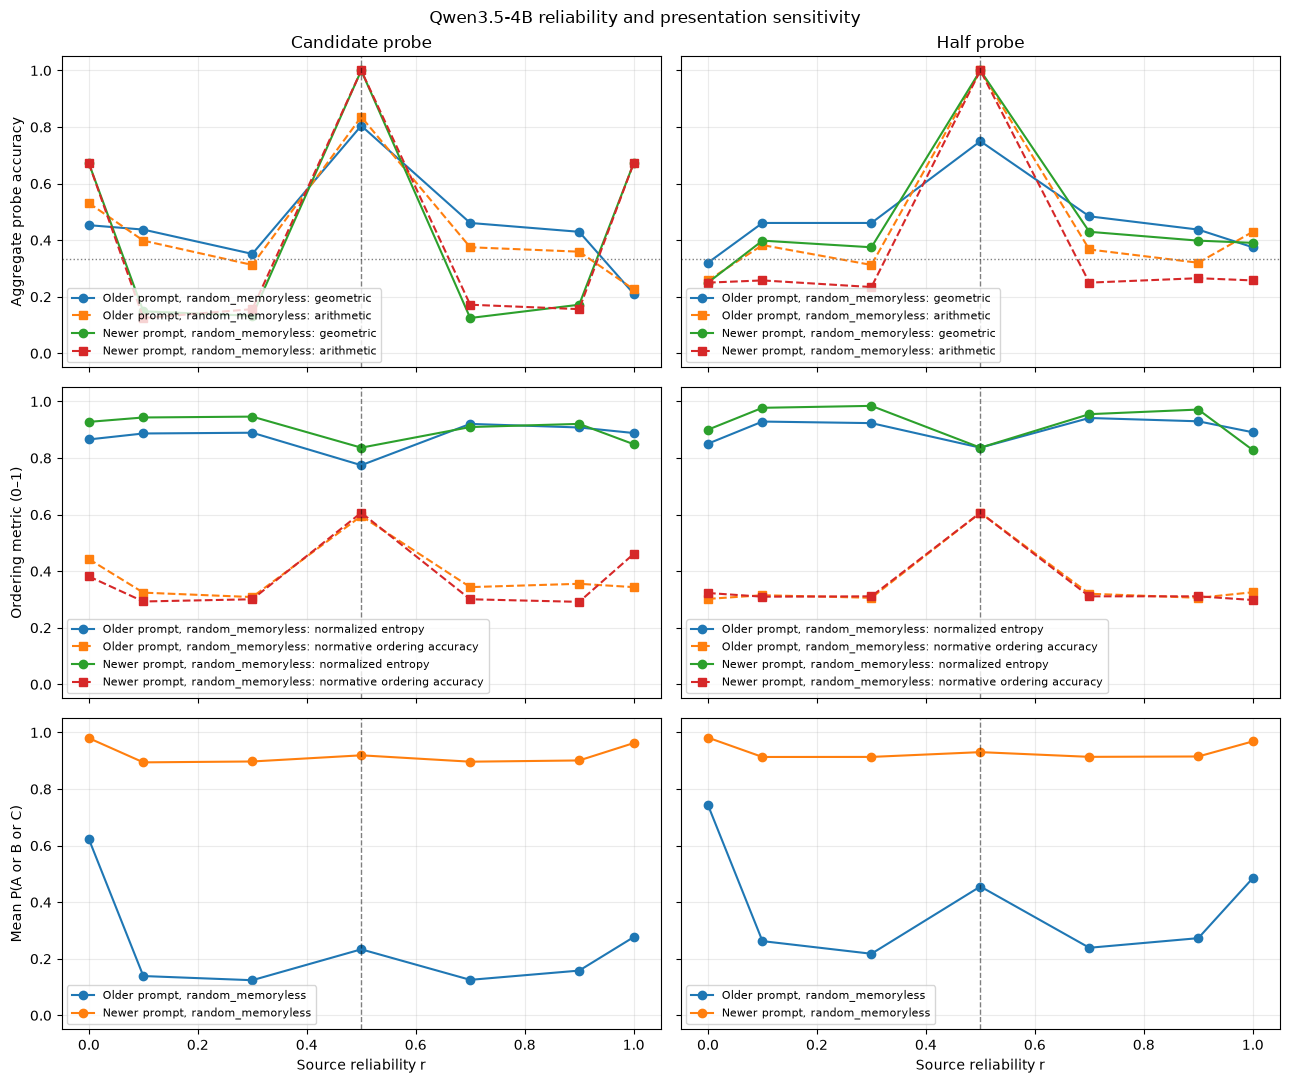

In [27]:
if "results" not in globals():
    results_path = ARTIFACT_DIR / "qwen_counterbalanced_results.jsonl"
    with results_path.open("r", encoding="utf-8") as handle:
        results = [json.loads(line) for line in handle if line.strip()]

required_analysis_fields = {
    "prompt_variant",
    "candidate_agreement_statistics",
    "arithmetic_correct",
    "normalized_permutation_prediction_entropy",
    "normative_permutation_accuracy",
    "mean_choice_probability_mass",
}
missing_analysis_fields = required_analysis_fields - set(results[0]) if results else set()
if not results or missing_analysis_fields:
    raise RuntimeError(
        "Rerun the model-scoring and evaluation cells to generate the expanded result schema. "
        f"Missing fields: {sorted(missing_analysis_fields)}"
    )


def grouped_mean(
    rows: Sequence[dict[str, object]], metric_key: str
) -> dict[tuple[str, str, str, float], float]:
    grouped: dict[tuple[str, str, str, float], list[float]] = {}
    for row in rows:
        key = (
            str(row["prompt_variant"]),
            str(row["policy"]),
            str(row["probe_kind"]),
            float(row["reliability"]),
        )
        grouped.setdefault(key, []).append(float(row[metric_key]))
    return {key: sum(values) / len(values) for key, values in grouped.items()}


geometric_accuracies = grouped_mean(results, "counterbalanced_correct")
arithmetic_accuracies = grouped_mean(results, "arithmetic_correct")
ordering_entropies = grouped_mean(
    results, "normalized_permutation_prediction_entropy"
)
normative_ordering_accuracies = grouped_mean(
    results, "normative_permutation_accuracy"
)
choice_probability_masses = grouped_mean(results, "mean_choice_probability_mass")
reliability_values = sorted(float(r) for r in RELIABILITIES)
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex="col", sharey="row")
for column, probe_kind in enumerate(("candidate", "half")):
    accuracy_axis = axes[0, column]
    ordering_axis = axes[1, column]
    choice_mass_axis = axes[2, column]
    for prompt_variant, policy in (
        (prompt_variant, policy)
        for prompt_variant in PROMPT_VARIANTS
        for policy in POLICIES
    ):
        prompt_label = PROMPT_VARIANT_LABELS[prompt_variant]
        keys = [
            (prompt_variant, policy, probe_kind, reliability)
            for reliability in reliability_values
        ]
        geometric_values = [
            geometric_accuracies.get(key, float("nan")) for key in keys
        ]
        arithmetic_values = [
            arithmetic_accuracies.get(key, float("nan")) for key in keys
        ]
        entropy_values = [
            ordering_entropies.get(key, float("nan")) for key in keys
        ]
        normative_ordering_values = [
            normative_ordering_accuracies.get(key, float("nan")) for key in keys
        ]
        choice_mass_values = [
            choice_probability_masses.get(key, float("nan")) for key in keys
        ]
        accuracy_axis.plot(
            reliability_values,
            geometric_values,
            marker="o",
            label=f"{prompt_label}, {policy}: geometric",
        )
        accuracy_axis.plot(
            reliability_values,
            arithmetic_values,
            marker="s",
            linestyle="--",
            label=f"{prompt_label}, {policy}: arithmetic",
        )
        ordering_axis.plot(
            reliability_values,
            entropy_values,
            marker="o",
            label=f"{prompt_label}, {policy}: normalized entropy",
        )
        ordering_axis.plot(
            reliability_values,
            normative_ordering_values,
            marker="s",
            linestyle="--",
            label=f"{prompt_label}, {policy}: normative ordering accuracy",
        )
        choice_mass_axis.plot(
            reliability_values,
            choice_mass_values,
            marker="o",
            label=f"{prompt_label}, {policy}",
        )
    accuracy_axis.axhline(1 / 3, color="gray", linestyle=":", linewidth=1)
    accuracy_axis.set_title(f"{probe_kind.capitalize()} probe")
    choice_mass_axis.set_xlabel("Source reliability r")
    for axis in (accuracy_axis, ordering_axis, choice_mass_axis):
        axis.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
        axis.set_ylim(-0.05, 1.05)
        axis.grid(alpha=0.25)
    accuracy_axis.legend(loc="best", fontsize=8)
    ordering_axis.legend(loc="best", fontsize=8)
    choice_mass_axis.legend(loc="best", fontsize=8)
axes[0, 0].set_ylabel("Aggregate probe accuracy")
axes[1, 0].set_ylabel("Ordering metric (0–1)")
axes[2, 0].set_ylabel("Mean P(A or B or C)")
fig.suptitle("Qwen3.5-4B reliability and presentation sensitivity")
fig.tight_layout()
plt.show()

## Reliability-selectable semantic confusion matrices

Use the prompt dropdown and reliability slider to inspect row-normalized confusion matrices separately for candidate and half-domain probes. Rows are exact Bayesian (`normative`) meanings and columns are predicted meanings; annotations show the observation count and row percentage. The aggregation selector switches between the retained geometric aggregate and the arithmetic aggregate.

In [28]:
def semantic_confusion_counts(
    rows: Sequence[dict[str, object]],
    reliability: float,
    policy: str,
    prompt_variant: str,
    probe_kind: str,
    prediction_key: str,
) -> list[list[int]]:
    counts = [
        [0 for _ in SEMANTIC_CHOICES]
        for _ in SEMANTIC_CHOICES
    ]
    for row in rows:
        if (
            float(row["reliability"]) != reliability
            or str(row["policy"]) != policy
            or str(row["prompt_variant"]) != prompt_variant
            or str(row["probe_kind"]) != probe_kind
        ):
            continue
        normative = str(row["normative_semantic_choice"])
        predicted = str(row[prediction_key])
        counts[SEMANTIC_CHOICES.index(normative)][
            SEMANTIC_CHOICES.index(predicted)
        ] += 1
    return counts


def plot_reliability_confusions(
    reliability: float, policy: str, prompt_variant: str, prediction_key: str
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    image = None
    for axis, probe_kind in zip(axes, ("candidate", "half")):
        counts = semantic_confusion_counts(
            results, reliability, policy, prompt_variant, probe_kind, prediction_key
        )
        row_totals = [sum(row) for row in counts]
        normalized = [
            [count / total if total else 0.0 for count in row]
            for row, total in zip(counts, row_totals)
        ]
        image = axis.imshow(normalized, vmin=0, vmax=1, cmap="Blues")
        axis.set_xticks(range(len(SEMANTIC_CHOICES)), SEMANTIC_CHOICES)
        axis.set_yticks(range(len(SEMANTIC_CHOICES)), SEMANTIC_CHOICES)
        axis.set_xlabel("Predicted semantic choice")
        axis.set_ylabel("Normative semantic choice")
        diagonal = sum(counts[i][i] for i in range(len(SEMANTIC_CHOICES)))
        total = sum(row_totals)
        accuracy = diagonal / total if total else float("nan")
        axis.set_title(f"{probe_kind.capitalize()} probe (accuracy={accuracy:.3f})")
        for row_index, row in enumerate(normalized):
            for column_index, proportion in enumerate(row):
                color = "white" if proportion > 0.5 else "black"
                axis.text(
                    column_index,
                    row_index,
                    f"{counts[row_index][column_index]}\n{proportion:.1%}",
                    ha="center",
                    va="center",
                    color=color,
                )
    if image is not None:
        fig.colorbar(image, ax=axes, label="Fraction within normative class")
    aggregation_name = (
        "geometric"
        if prediction_key == "predicted_semantic_choice"
        else "arithmetic"
    )
    fig.suptitle(
        f"Semantic confusion at r={reliability:g} — {policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — {aggregation_name}"
    )
    plt.show()


reliability_options = [
    (f"r={reliability:g}", reliability) for reliability in reliability_values
]
prompt_options = [
    (PROMPT_VARIANT_LABELS[prompt_variant], prompt_variant)
    for prompt_variant in PROMPT_VARIANTS
]
default_reliability = 0.9 if 0.9 in reliability_values else reliability_values[-1]
default_prompt_variant = "newer" if "newer" in PROMPT_VARIANTS else PROMPT_VARIANTS[0]
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the reliability slider.")
    plot_reliability_confusions(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "predicted_semantic_choice",
    )
else:
    reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    confusion_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric aggregate", "predicted_semantic_choice"),
            ("Arithmetic aggregate", "arithmetic_predicted_semantic_choice"),
        ],
        value="predicted_semantic_choice",
        description="Aggregation",
    )
    confusion_output = widgets.interactive_output(
        plot_reliability_confusions,
        {
            "reliability": reliability_slider,
            "policy": policy_selector,
            "prompt_variant": confusion_prompt_selector,
            "prediction_key": aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                reliability_slider,
                policy_selector,
                confusion_prompt_selector,
                aggregation_selector,
            ]
        ),
        confusion_output,
    )

Output()

## Candidate agreement counts versus semantic probability

For candidate $x$, define $a_x$ as the number of observations whose reported YES/NO answer agrees with the answer implied by $x$. With $T$ observations, the candidate's likelihood is $r^{a_x}(1-r)^{T-a_x}$, so $(a_{\mathrm{left}},a_{\mathrm{right}})$ is sufficient for the candidate-pair comparison at fixed $r$. The 3D plot uses those two agreement counts and the counterbalanced conditional semantic probability as its axes. It fixes the prompt variant and reliability and draws one point per transcript/repeat for each semantic probability; it does not average probabilities across examples or repeats. The geometric aggregate is the recommended default because averaging conditional log probabilities preserves the additive-logit label-bias cancellation. The selector also exposes the arithmetic mean, which instead estimates the expected conditional probability under a uniformly randomized ordering.

In [29]:
def plot_candidate_agreement_probabilities(
    reliability: float, policy: str, prompt_variant: str, probability_key: str
) -> None:
    candidate_rows = [
        row
        for row in results
        if row["probe_kind"] == "candidate"
        and float(row["reliability"]) == reliability
        and str(row["policy"]) == policy
        and str(row["prompt_variant"]) == prompt_variant
    ]
    if not candidate_rows:
        raise ValueError(
            f"No candidate-probe results for reliability={reliability}, "
            f"policy={policy}, and prompt={prompt_variant}."
        )
    required_agreement_fields = {
        "left_candidate_agreement_count",
        "right_candidate_agreement_count",
    }
    if any(
        row.get("candidate_agreement_statistics") is None
        or not required_agreement_fields.issubset(
            row["candidate_agreement_statistics"]
        )
        for row in candidate_rows
    ):
        raise RuntimeError(
            "Rerun transcript serialization and model evaluation to add "
            "candidate agreement statistics."
        )

    left_agreement_counts = [
        int(
            row["candidate_agreement_statistics"]
            ["left_candidate_agreement_count"]
        )
        for row in candidate_rows
    ]
    right_agreement_counts = [
        int(
            row["candidate_agreement_statistics"]
            ["right_candidate_agreement_count"]
        )
        for row in candidate_rows
    ]
    colors = {"left": "tab:blue", "right": "tab:orange", "tie": "tab:green"}
    markers = {"left": "o", "right": "s", "tie": "^"}
    fig = plt.figure(figsize=(10, 7))
    axis = fig.add_subplot(111, projection="3d")
    for semantic in SEMANTIC_CHOICES:
        probabilities = [
            float(row[probability_key][semantic]) for row in candidate_rows
        ]
        axis.scatter(
            left_agreement_counts,
            right_agreement_counts,
            probabilities,
            s=42,
            alpha=0.55,
            color=colors[semantic],
            marker=markers[semantic],
            label=semantic,
        )
    axis.set_xticks(
        range(min(left_agreement_counts), max(left_agreement_counts) + 1)
    )
    axis.set_yticks(
        range(min(right_agreement_counts), max(right_agreement_counts) + 1)
    )
    axis.set_zlim(-0.02, 1.02)
    axis.set_xlabel("Answers agreeing with left candidate")
    axis.set_ylabel("Answers agreeing with right candidate")
    axis.set_zlabel("Counterbalanced conditional semantic probability")
    aggregation_name = (
        "geometric"
        if probability_key == "geometric_mean_semantic_probabilities"
        else "arithmetic"
    )
    axis.set_title(
        f"Candidate agreement counts at r={reliability:g} — {policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — {aggregation_name} "
        f"({len(candidate_rows)} transcript/repeat points per semantic)"
    )
    axis.grid(alpha=0.25)
    axis.view_init(elev=24, azim=-55)
    axis.legend(title="Semantic choice")
    fig.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the candidate-agreement controls.")
    plot_candidate_agreement_probabilities(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "geometric_mean_semantic_probabilities",
    )
else:
    candidate_agreement_reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    candidate_agreement_policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    candidate_agreement_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    probability_aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric mean (recommended)", "geometric_mean_semantic_probabilities"),
            ("Arithmetic mean", "arithmetic_mean_semantic_probabilities"),
        ],
        value="geometric_mean_semantic_probabilities",
        description="Aggregation",
    )
    candidate_agreement_output = widgets.interactive_output(
        plot_candidate_agreement_probabilities,
        {
            "reliability": candidate_agreement_reliability_slider,
            "policy": candidate_agreement_policy_selector,
            "prompt_variant": candidate_agreement_prompt_selector,
            "probability_key": probability_aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                candidate_agreement_reliability_slider,
                candidate_agreement_policy_selector,
                candidate_agreement_prompt_selector,
                probability_aggregation_selector,
            ]
        ),
        candidate_agreement_output,
    )

Output()

## Agreement-pair averages versus semantic probability

This second 3D view groups transcript/repeat rows that have the same sufficient-statistic pair $(a_{\mathrm{left}},a_{\mathrm{right}})$ and plots their mean conditional semantic probabilities. Marker area increases with the number of rows in the group. Comparing this grouped view with the raw-point view above makes variation among transcripts with the same normative candidate-pair evidence easier to see.

In [30]:
def plot_grouped_candidate_agreement_probabilities(
    reliability: float,
    policy: str,
    prompt_variant: str,
    probability_key: str,
) -> None:
    candidate_rows = [
        row
        for row in results
        if row["probe_kind"] == "candidate"
        and float(row["reliability"]) == reliability
        and str(row["policy"]) == policy
        and str(row["prompt_variant"]) == prompt_variant
    ]
    if not candidate_rows:
        raise ValueError(
            f"No candidate-probe results for reliability={reliability}, "
            f"policy={policy}, and prompt={prompt_variant}."
        )
    required_agreement_fields = {
        "left_candidate_agreement_count",
        "right_candidate_agreement_count",
    }
    if any(
        row.get("candidate_agreement_statistics") is None
        or not required_agreement_fields.issubset(
            row["candidate_agreement_statistics"]
        )
        for row in candidate_rows
    ):
        raise RuntimeError(
            "Rerun transcript serialization and model evaluation to add "
            "candidate agreement statistics."
        )

    grouped_rows: dict[tuple[int, int], list[dict[str, object]]] = {}
    for row in candidate_rows:
        statistics = row["candidate_agreement_statistics"]
        agreement_pair = (
            int(statistics["left_candidate_agreement_count"]),
            int(statistics["right_candidate_agreement_count"]),
        )
        grouped_rows.setdefault(agreement_pair, []).append(row)
    agreement_pairs = sorted(grouped_rows)
    left_agreement_counts = [pair[0] for pair in agreement_pairs]
    right_agreement_counts = [pair[1] for pair in agreement_pairs]
    marker_sizes = [
        36 + 12 * len(grouped_rows[pair]) for pair in agreement_pairs
    ]
    colors = {"left": "tab:blue", "right": "tab:orange", "tie": "tab:green"}
    markers = {"left": "o", "right": "s", "tie": "^"}
    fig = plt.figure(figsize=(10, 7))
    axis = fig.add_subplot(111, projection="3d")
    for semantic in SEMANTIC_CHOICES:
        mean_probabilities = [
            sum(
                float(row[probability_key][semantic])
                for row in grouped_rows[pair]
            )
            / len(grouped_rows[pair])
            for pair in agreement_pairs
        ]
        axis.scatter(
            left_agreement_counts,
            right_agreement_counts,
            mean_probabilities,
            s=marker_sizes,
            alpha=0.75,
            color=colors[semantic],
            marker=markers[semantic],
            label=semantic,
        )
    axis.set_xticks(sorted(set(left_agreement_counts)))
    axis.set_yticks(sorted(set(right_agreement_counts)))
    axis.set_xlabel("Answers agreeing with left candidate")
    axis.set_ylabel("Answers agreeing with right candidate")
    axis.set_zlim(-0.02, 1.02)
    axis.set_zlabel("Counterbalanced conditional semantic probability")
    aggregation_name = (
        "geometric"
        if probability_key == "geometric_mean_semantic_probabilities"
        else "arithmetic"
    )
    axis.set_title(
        f"Mean probability by candidate agreement pair at r={reliability:g} — "
        f"{policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — "
        f"{aggregation_name} ({len(agreement_pairs)} pairs from "
        f"{len(candidate_rows)} rows)"
    )
    axis.grid(alpha=0.25)
    axis.view_init(elev=24, azim=-55)
    axis.legend(title="Semantic choice")
    fig.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the grouped-agreement controls.")
    plot_grouped_candidate_agreement_probabilities(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "geometric_mean_semantic_probabilities",
    )
else:
    grouped_agreement_reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    grouped_agreement_policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    grouped_agreement_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    grouped_agreement_aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric mean (recommended)", "geometric_mean_semantic_probabilities"),
            ("Arithmetic mean", "arithmetic_mean_semantic_probabilities"),
        ],
        value="geometric_mean_semantic_probabilities",
        description="Aggregation",
    )
    grouped_agreement_output = widgets.interactive_output(
        plot_grouped_candidate_agreement_probabilities,
        {
            "reliability": grouped_agreement_reliability_slider,
            "policy": grouped_agreement_policy_selector,
            "prompt_variant": grouped_agreement_prompt_selector,
            "probability_key": grouped_agreement_aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                grouped_agreement_reliability_slider,
                grouped_agreement_policy_selector,
                grouped_agreement_prompt_selector,
                grouped_agreement_aggregation_selector,
            ]
        ),
        grouped_agreement_output,
    )

Output()

## Total accuracy by prompt across reliability

This final chart is the direct A/B comparison. It plots the primary geometric counterbalanced accuracy for each prompt variant at every reliability, pooling candidate and half-domain probes across all configured policies, secrets, and repeats. Because prompt variants use matched observations and probes, every point compares the same underlying decisions.

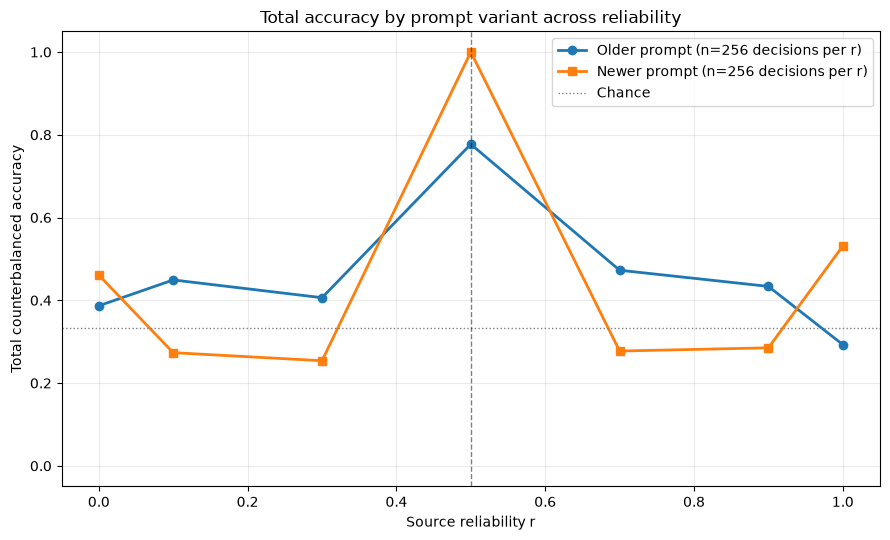

In [31]:
def total_accuracy_by_prompt(
    rows: Sequence[dict[str, object]],
) -> tuple[
    dict[tuple[str, float], float],
    dict[tuple[str, float], int],
]:
    grouped: dict[tuple[str, float], list[float]] = {}
    for row in rows:
        key = (str(row["prompt_variant"]), float(row["reliability"]))
        grouped.setdefault(key, []).append(
            float(row["counterbalanced_correct"])
        )
    accuracies = {
        key: sum(values) / len(values) for key, values in grouped.items()
    }
    counts = {key: len(values) for key, values in grouped.items()}
    return accuracies, counts


total_prompt_accuracies, total_prompt_counts = total_accuracy_by_prompt(results)
expected_total_keys = {
    (prompt_variant, reliability)
    for prompt_variant in PROMPT_VARIANTS
    for reliability in reliability_values
}
missing_total_keys = expected_total_keys - set(total_prompt_accuracies)
if missing_total_keys:
    raise RuntimeError(
        "Prompt comparison is incomplete; rerun the full evaluation grid. "
        f"Missing groups: {sorted(missing_total_keys)}"
    )
for reliability in reliability_values:
    matched_counts = {
        total_prompt_counts[(prompt_variant, reliability)]
        for prompt_variant in PROMPT_VARIANTS
    }
    if len(matched_counts) != 1:
        raise RuntimeError(
            f"Prompt variants have unmatched sample counts at r={reliability:g}: "
            f"{sorted(matched_counts)}"
        )

fig, axis = plt.subplots(figsize=(9, 5.5))
markers = {"older": "o", "newer": "s"}
for prompt_variant in PROMPT_VARIANTS:
    accuracy_values = [
        total_prompt_accuracies[(prompt_variant, reliability)]
        for reliability in reliability_values
    ]
    counts = [
        total_prompt_counts[(prompt_variant, reliability)]
        for reliability in reliability_values
    ]
    count_label = (
        f"n={counts[0]} decisions per r"
        if len(set(counts)) == 1
        else f"n={min(counts)}–{max(counts)} decisions per r"
    )
    axis.plot(
        reliability_values,
        accuracy_values,
        marker=markers.get(prompt_variant, "o"),
        linewidth=2,
        label=f"{PROMPT_VARIANT_LABELS[prompt_variant]} ({count_label})",
    )
axis.axhline(1 / 3, color="gray", linestyle=":", linewidth=1, label="Chance")
axis.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
axis.set_ylim(-0.05, 1.05)
axis.set_xlabel("Source reliability r")
axis.set_ylabel("Total counterbalanced accuracy")
axis.set_title("Total accuracy by prompt variant across reliability")
axis.grid(alpha=0.25)
axis.legend(loc="best")
fig.tight_layout()
plt.show()